# TP1 - Previsão de Preços de Carros Usados (Notebook Otimizado)

## Estratégias de Otimização Implementadas:

* **Feature Engineering Estável:** Correção de *ratio features* e remoção de polinómios instáveis para estabilidade do `StandardScaler`.
* **Treino Mais Profundo (Melhor Score):** Modo `full` com CV=5 e grades de hiperparâmetros mais extensas para combater o *underfitting* (alto viés).
* **Maior Velocidade:** Uso de `n_jobs=-1` em todas as etapas de validação cruzada.
* **Ensemble:** Adição de um `VotingRegressor` para combinar os melhores modelos e melhorar a precisão final.

In [52]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, cross_val_score, KFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, VotingRegressor
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, r2_score
import warnings
import os, joblib
import re, datetime
from IPython.display import display
import random

# Configuração
warnings.filterwarnings('ignore')
RANDOM_STATE = 42

# Reproducibilidade
os.environ['PYTHONHASHSEED'] = str(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)

# Define o número de núcleos a usar no treino. -1 usa todos os núcleos disponíveis.
TRAIN_N_JOBS = -1
# "None" para sem limite
SAMPLE_SIZE = None

print('Bibliotecas carregadas e Sementes definidas.')

Bibliotecas carregadas e Sementes definidas.


# Configuração de Execução

Esta célula define os parâmetros globais que controlam o equilíbrio entre velocidade e precisão do treino.

* **`MODE`**: Define o perfil de execução.
    * **`"quick"`**: Modo rápido para testes e debugging. Usa menos dobras de validação e menos iterações de busca.
    * **`"full"`**: Modo completo para produção. Executa uma busca exaustiva para encontrar o melhor modelo possível (pode demorar bastante).

* **`CV_FOLDS` (Cross-Validation Folds)**: Número de divisões do dataset para validação cruzada.
    * Ex: Se `CV_FOLDS=5`, o modelo é treinado 5 vezes (80% treino / 20% validação em cada rodada). Garante que o score é robusto.

* **`N_INTER_SEARCH`**: Número de iterações no `RandomizedSearchCV`.
    * Define quantas combinações aleatórias de hiperparâmetros serão testadas. Quanto maior, maior a chance de encontrar a configuração ideal, mas maior o tempo de processamento.

In [53]:
MODE = 'quick'

if MODE == 'quick':
    CV_FOLDS = 3
    N_ITER_SEARCH = 10
    print("MODO RÁPIDO ATIVADO: O treino será acelerado.")
else:
    CV_FOLDS = 5 
    N_ITER_SEARCH = 25 
    print("MODO COMPLETO ATIVADO: O treino será exaustivo e visará o melhor score.")

TARGET_LOG = True  
print(f'CV_FOLDS={CV_FOLDS}; TARGET_LOG={TARGET_LOG}; TRAIN_N_JOBS={TRAIN_N_JOBS}')

MODO RÁPIDO ATIVADO: O treino será acelerado.
CV_FOLDS=3; TARGET_LOG=True; TRAIN_N_JOBS=-1


# carregar o dataset

In [54]:
try:
    df = pd.read_csv('../data/train.csv')
    test = pd.read_csv('../data/test.csv')
    submission_template = pd.read_csv('../data/sample_submission.csv')
    print("Dados carregados (train.csv, test.csv, sample_submission.csv)")
except FileNotFoundError:
    print("ERRO: Ficheiros CSV não encontrados na pasta atual. Certifique-se que 'train.csv', 'test.csv' e 'sample_submission.csv' estão presentes.")
    raise
    
print(f"Dimensões do Dataset Treino: {df.shape}")

Dados carregados (train.csv, test.csv, sample_submission.csv)
Dimensões do Dataset Treino: (188533, 13)


## 🛠️ Feature Engineering

Esta secção prepara as variáveis de forma simples e robusta para melhorar o treino do modelo.

1. Normalização e limpeza:
- Uniformiza o nome da coluna de quilometragem.
- Extrai valores numéricos de texto (potência e litros) com padrões simples.

2. Features temporais:
- Cria a idade do veículo com base no ano do modelo.

3. Flags binárias:
- Gera indicadores para acidente, título limpo e transmissão automática.

4. Razões úteis:
- Potência por litro e quilometragem por ano, com proteção contra zeros e ausências.

5. Categorias simples:
- Agrupa idade e potência em faixas intuitivas para capturar tendências.

6. Marcas de luxo:
- Identifica marcas premium com um indicador simples.

No final, as frequências de marca/modelo e o agrupamento de cauda longa são calculados com base apenas no conjunto de treino, garantindo consistência e evitando fuga de informação.

In [ ]:
# === FEATURE ENGINEERING SIMPLIFICADA ===
current_year = 2025

def extract_number(s, pattern):
    """Extrai o primeiro número que corresponde ao padrão regex fornecido."""
    if pd.isna(s): return np.nan
    m = re.search(pattern, str(s), flags=re.I)
    return float(m.group(1)) if m else np.nan

def apply_fe(data):
    df = data.copy()
    
    # 1. Normalização e Limpeza
    if 'mileage' in df.columns:
        df.rename(columns={'mileage': 'milage'}, inplace=True)

    # Extração de números (HP e Litros)
    df['hp'] = df['engine'].apply(lambda x: extract_number(x, r"(\d+\.?\d*)\s*(?:HP|bhp|PS)"))
    df['displ_l'] = df['engine'].apply(lambda x: extract_number(x, r"(\d+\.?\d*)\s*[lL]"))
    
    # Limpeza de milhagem (remove vírgulas e converte para float)
    if df['milage'].dtype == 'O':
        df['milage'] = df['milage'].astype(str).str.replace(',', '').str.extract(r"(\d+\.?\d*)")[0].astype(float)

    # 2. Features Temporais
    df['age'] = current_year - pd.to_numeric(df['model_year'], errors='coerce')
    
    # 3. Flags Binárias (Converte 'Yes'/'True' para 1 e  0)
    for col in ['accident', 'clean_title']:
        df[f"{col}_flag"] = df.get(col, pd.Series(0)).astype(str).str.lower().isin(['yes', 'true', '1', 'y', 'sim']).astype(int)
    
    df['is_automatic'] = df['transmission'].astype(str).str.lower().str.contains('auto', na=False).astype(int)

    # 4. Ratios e Métricas Derivadas
    # Preenchimento temporário para cálculos seguros (evita divisão por zero)
    _hp = df['hp'].fillna(df['hp'].median())
    _milage = df['milage'].fillna(df['milage'].median())
    _age = df['age'].fillna(df['age'].median()).replace(0, 1) 
    _displ = df['displ_l'].fillna(df['displ_l'].median()).replace(0, 0.1)
    
    df['hp_per_liter'] = _hp / _displ
    df['milage_per_year'] = _milage / _age
    
    # 5. Categorias de Idade e Potência
    df['age_category'] = pd.cut(df['age'], bins=[-1, 3, 7, 15, 100], labels=['novo', 'usado', 'velho', 'antigo'])
    df['hp_category'] = pd.cut(df['hp'].fillna(0), bins=[0, 150, 250, 400, 700], labels=['basico', 'potente', 'esportivo', 'super'])
    
    # 6. Marcas de Luxo
    luxury_brands = ['BMW', 'Mercedes-Benz', 'Audi', 'Lexus', 'Porsche', 'Land Rover', 'Jaguar']
    df['is_luxury'] = df['brand'].isin(luxury_brands).astype(int)
    
    return df

# Aplicação da Feature Engineering
df = apply_fe(df)
test = apply_fe(test)

# 7. Frequência de Marca/Modelo e Agrupamento (Global)
# Garante que o encoding usa as estatísticas do TREINO para ambos os datasets
for col in ['brand', 'model']:
    # Calcula frequências apenas no treino
    freq_map = df[col].value_counts(normalize=True)
    
    # Mapeia frequências
    df[f'{col}_freq'] = df[col].map(freq_map).fillna(0)
    test[f'{col}_freq'] = test[col].map(freq_map).fillna(0)
    
    # Agrupamento de cauda longa (mantém top 20, resto vira 'Other')
    top_items = freq_map.nlargest(20).index
    df[f'{col}_grp'] = df[col].where(df[col].isin(top_items), 'Other')
    test[f'{col}_grp'] = test[col].where(test[col].isin(top_items), 'Other')

print(f"Feature Engineering concluida. ({df.shape[1]} colunas)")

Feature Engineering concluida. (26 colunas)


In [ ]:
# FEATURES OTIMIZADAS
features = [
    # Originais
    'model_year', 'age', 'milage', 'hp', 'displ_l',
    'brand_grp', 'brand_freq', 'model_grp', 'model_freq',
    'fuel_type', 'transmission', 'accident_flag', 'clean_title_flag',

    # NOVAS - Ratios & Interações
    'hp_per_liter', 'milage_per_year',

    # NOVAS - Categorias
    'age_category', 'hp_category',

    # NOVAS - Flags
    'is_luxury', 'is_automatic'
]

# Filtrar apenas as existentes
features = [c for c in features if c in df.columns]
X = df[features].copy()

# Tratamento de infinitos (Garantia de que o imputador lida com eles)
X = X.replace([np.inf, -np.inf], np.nan)

# Target
y_raw = df['price'].copy()
if TARGET_LOG:
    y = np.log1p(y_raw)
else:
    y = y_raw.copy()

# Identificar tipos de colunas
numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = [c for c in X.columns if c not in numeric_features]

# PIPELINE DE PREPROCESSAMENTO
num_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    # sparse_output=False para regressão e ensemble
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_transformer, numeric_features),
        ('cat', cat_transformer, categorical_features)
    ],
    remainder='passthrough', 
    n_jobs=TRAIN_N_JOBS
)

print(f"Pipeline preparado para {len(features)} features.")

Pipeline preparado para 13 features.


In [57]:
# Split Treino / Validação
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)

# Função para avaliação (usa RMSE na escala original ($) e R2)
def evaluate_model(pipe, X_val, y_val, name='model'):
    preds = pipe.predict(X_val)
    
    # Valores originais para cálculo do erro real ($)
    y_true_orig = np.expm1(y_val) if TARGET_LOG else y_val
    preds_orig = np.expm1(preds) if TARGET_LOG else preds
    
    # Remove a log1p que não pode resultar em valores negativos
    preds_orig = np.clip(preds_orig, 0, None)

    rmse = np.sqrt(mean_squared_error(y_true_orig, preds_orig))
    r2 = r2_score(y_true_orig, preds_orig)
    return {'name': name, 'rmse': rmse, 'r2': r2}

print(f"Treino: {X_train.shape}, Validação: {X_val.shape}")

Treino: (150826, 13), Validação: (37707, 13)


In [58]:
models = []
print('Preparando grelhas de modelos: MODE=', MODE)

def grid_choice(small, large):
    return small if MODE == 'quick' else large
    
# --- 1. Linear Regression (Usar Ridge para regularização) ---
#models.append(('Linear', Pipeline([('pre', preprocessor),('model', Ridge(random_state=RANDOM_STATE))]), 
#               {'model__alpha': grid_choice([1.0, 10.0], [0.1, 1.0, 10.0, 100.0])}))

# --- 2. K-Nearest Neighbors (KNN) ---
#models.append(('KNN', Pipeline([('pre', preprocessor),('model', KNeighborsRegressor(n_jobs=TRAIN_N_JOBS))]), 
#               {'model__n_neighbors': grid_choice([5, 10], [5, 10, 15, 20]), 
#                'model__weights': ['uniform','distance']}))

# --- 3. Decision Tree ---
#models.append(('DTree', Pipeline([('pre', preprocessor),('model', DecisionTreeRegressor(random_state=RANDOM_STATE))]), 
#               {'model__max_depth': grid_choice([10, 20], [15, 25, 35]), 
#                'model__min_samples_leaf': grid_choice([1, 5], [1, 3, 5, 10])}))

# --- 4. Random Forest (Grade Aprofundada) ---
rf_grid = {'model__n_estimators': grid_choice([50, 100], [100, 300, 500]), 
           'model__max_depth': grid_choice([15, None], [20, 30, None]), 
           'model__min_samples_leaf': grid_choice([1, 3], [1, 2, 5])}
models.append(('RF', Pipeline([('pre', preprocessor),('model', RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=TRAIN_N_JOBS))]), rf_grid))

# --- 5. SVR (SVM) (Grade pequena devido ao tempo de treino) ---
#svr_grid = {'model__C': grid_choice([0.1, 1.0], [0.1, 1.0]), 
#            'model__kernel': ['rbf'], 
#            'model__gamma': ['scale','auto']}
#models.append(('SVR', Pipeline([('pre', preprocessor),('model', SVR())]), svr_grid))

# --- 6. MLP (Redes Neuronais, Grade Aprofundada) ---
#mlp_grid = {'model__hidden_layer_sizes': grid_choice([(50,),(100,)], [(100,),(100,50),(200,100)]), 
#            'model__alpha': grid_choice([0.0001], [0.0001, 0.001]),
#            'model__max_iter': grid_choice([500], [1000])} 
#models.append(('MLP', Pipeline([('pre', preprocessor),('model', MLPRegressor(random_state=RANDOM_STATE))]), mlp_grid))

print(f"Total de modelos a testar: {len(models)}")

Preparando grelhas de modelos: MODE= quick
Total de modelos a testar: 1


In [59]:
os.makedirs('../models', exist_ok=True)

# Salvar preprocessor
joblib.dump(preprocessor, '../models/preprocessor.joblib')
print('Preprocessor salvo em ../models/preprocessor.joblib')

results = []
summary_path = '../models/training_results_summary.csv'

X_train_work = X_train.copy()
y_train_work = y_train.copy()

cv = KFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)

for name, pipe, params in models:
    print(f'\n==== Treinando {name} com n_jobs={TRAIN_N_JOBS} ====')
    
    # RandomSearch para modelos mais complexos (RF, MLP, SVR) 
    use_random = (name in ['RF','MLP','SVR']) and (MODE != 'quick')
    
    if use_random:
        # RandomSearch com mais iterações
        gs = RandomizedSearchCV(pipe, params, cv=cv, scoring='neg_mean_squared_error', 
                                n_jobs=TRAIN_N_JOBS, verbose=1, n_iter=N_ITER_SEARCH, 
                                random_state=RANDOM_STATE)
    else:
        gs = GridSearchCV(pipe, params, cv=cv, scoring='neg_mean_squared_error', 
                          n_jobs=TRAIN_N_JOBS, verbose=1)
    try:
        gs.fit(X_train_work, y_train_work)
        best = gs.best_estimator_
        evals = evaluate_model(best, X_val, y_val, name=name)
        evals['best_params'] = getattr(gs, 'best_params_', None)
        
        # Cross-validation score
        cvs = cross_val_score(best, X_train_work, y_train_work, cv=cv, scoring='neg_mean_squared_error', n_jobs=TRAIN_N_JOBS)
        rmse_folds = np.sqrt(-cvs)
        evals['cv_rmse_mean'] = float(rmse_folds.mean())
        evals['cv_rmse_std'] = float(rmse_folds.std())
        
        # Save best estimator
        model_path = f"../models/{name}_best.joblib"
        joblib.dump(best, model_path)
        evals['saved_to'] = model_path
        results.append(evals)
        
        # Save partial summary
        tmp_df = pd.DataFrame(results).sort_values('rmse')
        tmp_df.to_csv(summary_path, index=False)
        print(f"RMSE Validation ({name}): {evals['rmse']:,.2f}")
        print('Partial summary saved.')
        
    except Exception as e:
        import traceback
        print(f'Erro ao treinar {name}: {e}')
        print(traceback.format_exc())
        results.append({'name':name, 'rmse':np.nan, 'r2':np.nan, 'best_params':None, 'saved_to':None, 'cv_rmse_mean':np.nan, 'cv_rmse_std':np.nan})

res_df = pd.DataFrame(results).sort_values('rmse')
# Save final results summary
res_df.to_csv(summary_path, index=False)
display(res_df)

Preprocessor salvo em ../models/preprocessor.joblib

==== Treinando RF com n_jobs=-1 ====
Fitting 3 folds for each of 8 candidates, totalling 24 fits
RMSE Validation (RF): 68,592.49
Partial summary saved.


,name,rmse,r2,best_params,cv_rmse_mean,cv_rmse_std,saved_to
0,RF,68592.491598,0.153962,"{'model__max_depth': 15, 'model__min_samples_l...",0.496686,0.004893,../models/RF_best.joblib


## Treino do Ensemble (Voting Regressor)

O `Voting Regressor` combina os modelos mais fortes (normalmente RF, Ridge/Lasso, e MLP/SVR) para obter uma previsão mais robusta. O seu treino usa os melhores estimadores já salvos para ser eficiente.

Erro ao tentar treinar o Ensemble. Detalhe: [Errno 2] No such file or directory: '../models/SVR_best.joblib'


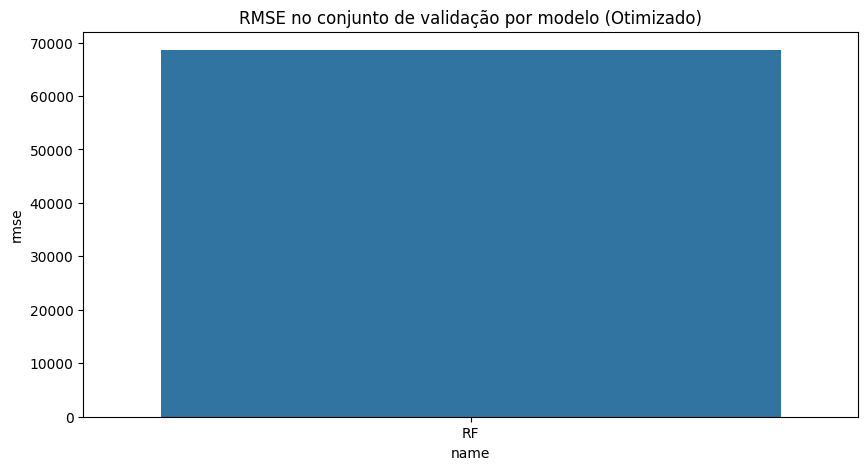

In [60]:
# Carregar os melhores estimadores salvos
try:
    best_rf = joblib.load('../models/RF_best.joblib')
    best_ridge = joblib.load('../models/Linear_best.joblib') 
    # Tenta usar MLP (melhor non-linear) ou SVR (fallback)
    try:
        best_third = joblib.load('../models/MLP_best.joblib')
        third_name = 'MLP'
    except:
        best_third = joblib.load('../models/SVR_best.joblib')
        third_name = 'SVR'
        
    
    # Definir os estimadores (apenas o modelo final, o preprocessor é externo)
    estimators = [
        ('rf', best_rf.named_steps['model']),
        ('ridge', best_ridge.named_steps['model']),
        (third_name.lower(), best_third.named_steps['model'])
    ]
    
    # Criar o pipeline do Ensemble (Pre-processor + Voting Regressor)
    ensemble_pipe = Pipeline([
        ('pre', preprocessor),
        ('voting', VotingRegressor(estimators=estimators, n_jobs=TRAIN_N_JOBS))
    ])
    
    print(f"Treinando Ensemble ({[e[0] for e in estimators]})...")
    # Treinar o ensemble no conjunto de treino completo
    ensemble_pipe.fit(X_train, y_train)
    
    # Avaliar e salvar o Ensemble
    ensemble_evals = evaluate_model(ensemble_pipe, X_val, y_val, name='Ensemble')
    joblib.dump(ensemble_pipe, '../models/Ensemble_best.joblib')
    print(f"Ensemble treinado e salvo. RMSE: ${ensemble_evals['rmse']:,.2f}")
    
    # Atualizar o resumo dos resultados
    if 'res_df' in locals():
        ensemble_evals['best_params'] = str(estimators)
        ensemble_evals['saved_to'] = '../models/Ensemble_best.joblib'
        ensemble_evals['cv_rmse_mean'] = np.nan
        ensemble_evals['cv_rmse_std'] = np.nan
        res_df = pd.concat([res_df, pd.DataFrame([ensemble_evals])]).sort_values('rmse').reset_index(drop=True)
        res_df.to_csv(summary_path, index=False)
        display(res_df)

except Exception as e:
    print(f'Erro ao tentar treinar o Ensemble. Detalhe: {e}')

# Exibir gráfico de comparação 
if 'res_df' in locals() and not res_df.empty:
    plt.figure(figsize=(10,5))
    sns.barplot(data=res_df, x='name', y='rmse')
    plt.title('RMSE no conjunto de validação por modelo (Otimizado)')
    plt.savefig('../models/rmse_comparison_optimized.png')
    plt.show()

## 📤 Geração da Submissão

Esta célula usa o modelo com o **melhor RMSE** (incluindo o Ensemble, se treinado) para gerar o ficheiro `submission.csv` para o Kaggle.

In [61]:
# ===== SUBMISSÃO FINAL =====
print("A gerar ficheiro de submissão...")

# 1. Carregar o melhor modelo (ou ensemble) com base no RMSE
summary = pd.read_csv('../models/training_results_summary.csv')
best_name = summary.sort_values('rmse').iloc[0]['name']
model_path = f'../models/{best_name}_best.joblib'

print(f"Carregando melhor modelo para submissão: {best_name} ({model_path})")
model = joblib.load(model_path)

# 2. Preparar X_test (já com FE aplicado no passo anterior)
# Garante que usa as mesmas features e trata inf/nan
X_test = test[features].copy() 
X_test = X_test.replace([np.inf, -np.inf], np.nan)

# 3. PREVISÃO
preds = model.predict(X_test)

# 4. Reverter log1p e garantir não-negativos
price_pred = np.expm1(preds) if TARGET_LOG else preds
price_pred = np.clip(price_pred, 0, None)

# 5. Geração do ficheiro
submission = pd.DataFrame({
    'id': test['id'],
    'price': price_pred
})

out_path = 'submission.csv'
submission.to_csv(out_path, index=False)

print(f"\nSUBMISSÃO GERADA COM SUCESSO!")
print(f"→ {out_path} (usando {best_name})")
print(f"→ Previsões: min=${price_pred.min():,.0f}, max=${price_pred.max():,.0f}, média=${price_pred.mean():,.0f}")
display(submission.head(10))

A gerar ficheiro de submissão...
Carregando melhor modelo para submissão: RF (../models/RF_best.joblib)

SUBMISSÃO GERADA COM SUCESSO!
→ submission.csv (usando RF)
→ Previsões: min=$4,938, max=$538,543, média=$36,625


,id,price
0,188533,15930.833007
1,188534,61731.438405
2,188535,49359.848943
3,188536,25588.242789
4,188537,28602.802283
5,188538,16434.420948
6,188539,8517.354103
7,188540,40751.084607
8,188541,63085.021693
9,188542,29804.718404
